In [1]:

import sys
sys.path.append('../.')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import astropy.stats as astro
import scipy
import sys
import matplotlib.gridspec as gridspec
sys.path.append("../../.'")

from AT_plots import polarPlot_largeDF, cart2pola, rel2Nest

/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/its/home/nn268/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
anttracks = pd.read_csv("/its/home/nn268/antvis/antvis/optics/Exp2_AntTracks/RealAnts_ALL_TRIM.csv")

print(anttracks.keys())

/tmp/ipykernel_126282/763836248.py:1: DtypeWarning: Columns (4,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  anttracks = pd.read_csv("/its/home/nn268/antvis/antvis/optics/Exp2_AntTracks/RealAnts_ALL_TRIM.csv")


Index(['Unnamed: 0.1', 'index', 'Unnamed: 0', 'Date', 'ID', 'frame', 'x', 'y',
       'Nest', 'Condition', 'Sector', 'Direction', 'DI', 'rad', 'theta',
       'dTheta', 'thetaR2N', 'deltaDist', 'accumDist', 'speed', 'time',
       'meanSpeed', 'dx', 'dy', 'trim_StraightnessIDX', 'trim_beeline',
       'trim_circR'],
      dtype='object')


In [347]:
anttracks['ID'] == anttracks['ID'].astype('str')
k = anttracks[(anttracks['Nest']== 'Wigwam')]
NN =  anttracks[(anttracks['Nest']== 'NewNest')]

CONDITIONS = np.unique(k['Condition'])

CONDITIONS = np.unique(k['Condition'])
print(CONDITIONS)

#print(NN)
print(np.unique(NN['Condition']))

Conditions_shared = ['On-route 1 ZV', 'Off-route 1 ZV', 'On-route 2 ZV', 'Unfamiliar FV', 'Unfamiliar ZV']

conditions_OR1 = ['On-route 1 ZV', 'On-route 1B ZV',  'Plus 3m ZV', 'Route 0m ZV']

condistions_distant = ['Unfamiliar ZV', 'Unfamiliar ZV 2', 'Unfamiliar ZV 3', 'Unfamiliar FV']

['Off-route 1 ZV' 'On-route 1 ZV' 'On-route 2 ZV' 'Unfamiliar FV'
 'Unfamiliar ZV']
['Minus 3m ZV' 'Off-route 1 ZV' 'On-route 1 ZV' 'On-route 1B ZV'
 'On-route 2 ZV' 'Plus 3m ZV' 'Route 0m ZV' 'Unfamiliar FV'
 'Unfamiliar ZV' 'Unfamiliar ZV 2' 'Unfamiliar ZV 3']


In [343]:
# number of ants per condition

newnest = anttracks[anttracks['Nest']== "NewNest"]
wigwam =  anttracks[anttracks['Nest']== "Wigwam"]

#print(len(newnest))
#print(len(wigwam))
newnestconds = np.unique(newnest['Condition'])

print(f"NewNEst Conditions :   {newnestconds}")
nnnumber=0
for c in newnestconds:
    cnest = newnest[newnest['Condition'] == c]
    cnest['ID'] == cnest['ID'].astype('str')
    nnnumber += len(np.unique(cnest['ID']))
    print(f"NewNest {c}  {len(np.unique(cnest['ID'].astype('str')))}")
    
print("  ")

wigwamconds = np.unique(wigwam['Condition'])
print(f"wigwam Conditions :   {wigwamconds}")
wwnumber = 0
for c in wigwamconds:
    cnest = wigwam[wigwam['Condition'] == c]
    cnest['ID'] == cnest['ID'].astype(str) #{'ID':'str'}
    print(cnest.dtypes)
    print(f"c : {c}")
    #for id in cnest['ID']:
    #    if isinstance(id, int):
    #        cnest['ID'] == cnest['ID'].astype('str')
    print(f"Wigwam {c}  {len(np.unique(cnest['ID'].astype('str')))}")
    wwnumber += len(np.unique(cnest['ID'].astype('str')))

print("")
print(f"TOTAL ANTS NEWNEST {nnnumber}")
print(f"TOTAL ANTS WIGWAM {wwnumber}")

NewNEst Conditions :   ['Minus 3m ZV' 'Off-route 1 ZV' 'On-route 1 ZV' 'On-route 1B ZV'
 'On-route 2 ZV' 'Plus 3m ZV' 'Route 0m ZV' 'Unfamiliar FV'
 'Unfamiliar ZV' 'Unfamiliar ZV 2' 'Unfamiliar ZV 3']
NewNest Minus 3m ZV  36
NewNest Off-route 1 ZV  65
NewNest On-route 1 ZV  69
NewNest On-route 1B ZV  64
NewNest On-route 2 ZV  66
NewNest Plus 3m ZV  34
NewNest Route 0m ZV  43
NewNest Unfamiliar FV  61
NewNest Unfamiliar ZV  69
NewNest Unfamiliar ZV 2  63
NewNest Unfamiliar ZV 3  63
  
wigwam Conditions :   ['Off-route 1 ZV' 'On-route 1 ZV' 'On-route 2 ZV' 'Unfamiliar FV'
 'Unfamiliar ZV']
Unnamed: 0.1              int64
index                   float64
Unnamed: 0              float64
Date                     object
ID                       object
frame                   float64
x                       float64
y                       float64
Nest                     object
Condition                object
Sector                   object
Direction                object
DI                  

In [5]:
63 + 67 +64 +67 +59

320

In [6]:
48+48+51+50+51

248

In [7]:
data_path = "/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/"

In [8]:
anttracks['ID']

0          NaN
1          270
2          270
3          270
4          270
          ... 
2609116    999
2609117    999
2609118    999
2609119    999
2609120    999
Name: ID, Length: 2609121, dtype: object

current functions below.
3.
take a df. 
subset the df.
calculate the stats
call function to create the polar and circ hist plot (per condition for one nest)


I want a subset of conditions
I want to tell the plotting function to look at specific nest and specific condtion
create fig, pass it out.

In [9]:
def polarPlot_overlayed_largeDF(df, specify=None, nest=None, indivcol = False, save=False, save_path='/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/'):

    if nest is not None:
        df = df[df['Nest']==nest]

            
    if specify is not None:
        df = df[df['Condition']==specify]

    #print(df)
    max_len = max(df['frame'])

    df_justfames = df.loc[:, ['ID', 'frame']] 

    framelist = df_justfames.groupby(['ID']).max()

    min_len = framelist.min()

    # I want the dynamic colour to be related to the condition. so do i need to split the df into condition type. then take the max len.
    conditions = [np.unique(df['Condition'])]
    conditions= conditions[0]
    
    for cond in conditions:
        print(cond)
        df_touse = df[df['Condition']== str(cond)]
        #print(np.unique([type(i) for i in df_touse['ID']]))
        
        max_len = max(df_touse['frame'])
        df_touse['ID'] = df_touse['ID'].astype(str)
        ids = np.unique(df_touse['ID'])
        nestname = ""
        print(str(np.unique(df_touse['Nest'])).lower())
        if str(np.unique(df_touse['Nest'])[0]).lower() == "wigwam":
            nestname = 'N1'
        elif str(np.unique(df_touse['Nest'])[0]).lower() == "newnest":
            nestname = 'N2'

        create_Overlayed_polar_plot2(df_touse, max_len, title=f"{nestname} {np.unique(df_touse['Condition'])[0]}", save=save, save_path=save_path) #  {np.unique(df_touse['ID'])} {(max(new_df['frame'])/25)/60:.2f}  {max(new_df['frame'])/25} seconds    = 


In [10]:
#             f = create_Overlayed_polar_plot3(df, cond, nest, title="")
def create_Overlayed_polar_plot3(fig, outer, df_coordinates, condition, nest, title:str, pindex='frame', save =False, xname='x', yname='y', bkgrnd=None, step =10, foodcentered =False, save_path='/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/'):
    # create plot base
    #fig = plt.figure(figsize=(10, 10)) #10, 10
    #ax2 = ax.add_subplot(222,projection='polar')
    #ax2 = fig.add_subplot(211, projection='polar')
    #ax3 = ax.add_subplot(212, projection='polar')
    inner = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=outer, wspace=0, hspace=0)
    ax2 = fig.add_subplot(inner[0], projection='polar')
    #ax3 =  fig.add_subplot(inner[1], projection='polar')

    
    alphaval = 1 # 0.1
    #print(f"PRE ASTYPE : type dfcoord['ID']  {type(df_coordinates['ID'][0])} {df_coordinates['ID'][0]}")
    df_coordinates['ID'] = df_coordinates['ID'].astype('str')
    #print(f"df coordinates  {df_coordinates}")
    #print(f"POST ASTYPE : type dfcoord['ID']  {type(df_coordinates['ID'][30])} {df_coordinates['ID'][30]}")
    
    longestdf = {'id': 0, 'length': 0, 'scat_ele' :0}
    final_heading_list = []
    cart_final_heading_list = []
    max_r = 0
    #print(np.unique(df_coordinates['Nest']))
    dfsubset = df_coordinates[(df_coordinates['Nest']==nest) & (df_coordinates['Condition']== condition)]
    #print(f"dfsubset   {dfsubset}")
    ids = np.unique(dfsubset['ID'])
    #dfsubset =dfsubset[]
    
    if bkgrnd is not None:
        implot = ax1.imshow(bkgrnd)

    for id in ids:
        #print(f"type of id {id} {type(id)}")
        #print(f"type of subset['id']  {dfsubset['ID'][0]}")
        newdf = dfsubset[dfsubset['ID']== id]
        #print(f"newdf   {newdf}")
        df_len = len(newdf)
        
        _x = np.array(newdf[xname])
        _y =  np.array(newdf[yname])
        dx_ = newdf[xname].diff(periods=1)
        dy_ = newdf[yname].diff(periods=1)
        
        if foodcentered:
            newx = np.array(newdf['new_x'])
            newy = np.array(newdf['new_y'])
            theta, r = cart2pola(newx, newy)
        #print(f"pre theta :  x {_x} ,  y {_y}")
        theta, r = cart2pola(_x, _y)
        #print(f"theta @ {theta}")
        theta = rel2Nest(theta)
        final_heading_list.append(theta[-1])
        
        if r[-1] > max_r:
            max_r = r[-1]
        
        # Plot the points
        scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 0.1, c='gray')#cmap="winter") #nipy_spectral gist_rainbow c=range(df_len),
        ax2.grid(False)
        
    
        # plot final pos
        #ax2.scatter(theta[-1], r[-1], alpha=alphaval, marker='$o$',s= 60, c= 'blue') 
        #ax2.scatter(theta[0], r[0], alpha=alphaval, marker='$o$',s= 60, c= 'red') 

        if df_len > longestdf['length']: # ensure that legend is created once
            longestdf['length'] = df_len
            longestdf['scat_ele'] = scatter2.legend_elements()

    #print(f"final headings:  {final_heading_list}")
    histn, histbins = np.histogram(final_heading_list, bins=36)
    histwidths = np.diff(histbins)
    histrad = histn# 310 ##[rad+2 if rad<=2 else rad for rad in histn]
    #print(f"hist rads {histrad} len{len(histrad)}  minus1 {len(histrad)-1}")
    
    final_heading_array = np.array(final_heading_list)
    rayleigh_ans = astro.rayleightest(final_heading_array) # astro rayleightest wants radians
    final_heading_listdeg = [np.rad2deg(i) for i in final_heading_list]
    #print(f"len histbins {len(histbins)}  len histrad {len(histrad)}   widths {len(histwidths)}")
    ax2.bar(histbins[:-1], histrad, align='edge', width= histwidths, bottom=300) #8 , 
    #if rayleigh_ans <= 0.05:
    #    mean_heading_theta = scipy.stats.circmean(final_heading_array) # circ mean wants radians
    #    var_heading_theta = scipy.stats.circvar(final_heading_array)
    #    std_heading_theta = scipy.stats.circstd(final_heading_array)
    #    #print(f"mean theta type {type(mean_heading_theta)} mean: {mean_heading_theta}")
    #    #print(f" mean head rad {mean_heading_theta}")
    #    #print(f" std head rad {std_heading_theta}")
    #    #print(f" var head rad {var_heading_theta}")
    # 
    #    #ax2.scatter(mean_heading_theta, max_r, alpha=0.4, marker='$o$',s= 60, c= 'k') 
    #    ax2.quiver(0,  # x mean_heading_theta
    #        0,      # y max_r
    #        np.cos(mean_heading_theta),  # V
    #        np.sin(mean_heading_theta),    # U [0]
    #        ec='k', scale=1)# 
    #    ax3.quiver(0,  # x mean_heading_theta
    #        0,      # y max_r
    #        np.cos(mean_heading_theta),  # V
    #        np.sin(mean_heading_theta),    # U [0]
    #        ec='k', scale=1)# 
    #    ax2.quiver(0,  # x mean_heading_theta
    #        0,      # y max_r
    #        np.cos(mean_heading_theta+var_heading_theta),  # V
    #        np.sin(mean_heading_theta+var_heading_theta),    # U [0]
    #        color='yellow', scale=1)# 
    #    ax2.quiver(0,  # x mean_heading_theta
    #        0,      # y max_r
    #        np.cos(mean_heading_theta-var_heading_theta),  # V
    #        np.sin(mean_heading_theta-var_heading_theta),    # U [0]
    #        color='yellow', scale=1)# 
    #    ax2.quiver(0,  # x mean_heading_theta
    #        0,      # y max_r
    #        np.cos(mean_heading_theta+var_heading_theta),  # V
    #        np.sin(mean_heading_theta+var_heading_theta),    # U [0]
    #        color='yellow', scale=1)# 
    #    ax2.quiver(0,  # x mean_heading_theta
    #        0,      # y max_r
    #        np.cos(mean_heading_theta-var_heading_theta),  # V
    #        np.sin(mean_heading_theta-var_heading_theta),    # U [0]
    #        color='yellow', scale=1)# 
    #    ax2.quiver(0,  # x mean_heading_theta
    #        0,      # y max_r
    #        np.cos(mean_heading_theta+std_heading_theta),  # V
    #        np.sin(mean_heading_theta+std_heading_theta),    # U [0]
    #        color='orange', scale=1)# 
    #    ax2.quiver(0,  # x mean_heading_theta
    #        0,      # y max_r
    #        np.cos(mean_heading_theta-std_heading_theta),  # V
    #        np.sin(mean_heading_theta-std_heading_theta),    # U [0]
    #        color='orange', scale=1)# 
    ##ax2.quiver(0,  # x mean_heading_theta
    #    0,      # y max_r
    #    np.cos(np.deg2rad(180)),  # V
    #    np.sin(np.deg2rad(180)),    # U [0]
    #    color='red', scale=1)# 
    #ax3.quiver(0,  # x mean_heading_theta
    #    0,      # y max_r
    #    np.cos(np.deg2rad(180)),  # V
    #    np.sin(np.deg2rad(180)),    # U [0]
    #    color='red', scale=1)# 
    ax2.set_yticklabels([])
    ax2.set_xticklabels([])
    #ax3.set_yticklabels([])
    #ax3.set_xticklabels([])

    plt.tight_layout()

    #if save == True:
    #    #cv2.imwrite(f"{save_path}{title}_hist.jpg", fig)
    #    plt.savefig(fname=save_path+title+"_hist"+".png", format='png')
    #    #cv2.imsave()
    
    #plt.show()
    #return ax2, ax3

In [11]:
def multiTrackplot2(df, conditions:list, w_space = -0.45, h_space=-0.01): #-0.45, 0.1

    df['ID'] == df['ID'].astype('str')

    print("num conditions : ",len(np.unique(conditions)))
    numrows = len(conditions) # int(np.ceil(len(rows)/2))
    print(f" number of rows : {numrows}")
    numcols = 2#len(cols)
    print(f" number of cols : {numcols}")

    fig = plt.figure(figsize=(10,22)) #22
    outer = gridspec.GridSpec(numrows, numcols, wspace=0, hspace=0.4)

    nests = np.unique(df['Nest'])
    print(nests)
    nests = [nests[1], nests[0]]
    print(nests)
    for i in range(numrows):
        for j in range(numcols):
            #inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[i,j], wspace=0.1, hspace=0.1)
            cond = conditions[i]
            nes = nests[j]
            create_Overlayed_polar_plot3(fig, outer[i,j], df, cond, nes, title="")#plot_image(axarr[i, j], df, cond, nes) # imagelist[i*2 +j]

    fig.text(0.25, 0.97, "Nest 1", ha='center', va='top', color= '#008000', fontsize =9)
    fig.text(0.75, 0.97, "Nest 2", ha='center', va='top', color= '#CC79A7', fontsize =9)

    for i, c in enumerate(conditions):
        y_pos = 0.84 - (i * (0.9/ numrows))
        fig.text(0.9, y_pos, c, rotation=90, va='center', ha='center', fontsize =10)

    fig.suptitle(f"Abbotts Woods Wood Ants initial heading (30cm) \n seporated by nest and condition", fontsize=10,  y=1)#0.99
    fig.tight_layout(rect=[0,0,1, 0.99])
    fig.show()

In [13]:
#multiTrackplot2(anttracks, CONDITIONS)

Landscape

In [14]:
def multiTrackplot2(df, conditions:list, w_space = -0.45, h_space=-0.01): #-0.45, 0.1

    df['ID'] == df['ID'].astype('str')

    print("num conditions : ",len(np.unique(conditions)))
    numcols = len(conditions) # int(np.ceil(len(rows)/2))
    
    numrows = 2#len(cols)
    print(f" number of cols : {numcols}")
    print(f" number of rows : {numrows}")

    fig = plt.figure(figsize=(10,22)) #22
    outer = gridspec.GridSpec(numrows, numcols, wspace=0, hspace=0)

    nests = np.unique(df['Nest'])
    print(nests)
    nests = [nests[1], nests[0]]
    print(nests)
    for i in range(numrows):
        for j in range(numcols):
            #inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[i,j], wspace=0.1, hspace=0.1)
            cond = conditions[j]
            nes = nests[i]
            create_Overlayed_polar_plot3(fig, outer[i,j], df, cond, nes, title="")#plot_image(axarr[i, j], df, cond, nes) # imagelist[i*2 +j]

    fig.text(0.25, 0.97, "Nest 1", ha='center', va='top', color= '#008000', fontsize =9)
    fig.text(0.75, 0.97, "Nest 2", ha='center', va='top', color= '#CC79A7', fontsize =9)

    for i, c in enumerate(conditions):
        y_pos = 0.84 - (i * (0.9/ numrows))
        fig.text(0.9, y_pos, c, rotation=90, va='center', ha='center', fontsize =10)

    fig.suptitle(f"Abbotts Woods Wood Ants initial heading (30cm) \n seporated by nest and condition", fontsize=10,  y=1)#0.99
    fig.tight_layout(rect=[0,0,1, 0.99])
    fig.show()

In [15]:
multiTrackplot2(anttracks, CONDITIONS)

num conditions :  5
 number of cols : 5
 number of rows : 2


TypeError: '<' not supported between instances of 'str' and 'float'

<Figure size 1000x2200 with 0 Axes>

In [369]:
#             f = create_Overlayed_polar_plot3(df, cond, nest, title="")
from scipy.interpolate import interp1d
def create_Overlayed_polar_plot3(fig, i, j,numrows, numcols, df_coordinates, condition, nest, title:str, pindex='frame', save =False, xname='x', yname='y', bkgrnd=None, step =10, foodcentered =False, save_path='/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/abbotsplots/multipath/'):
    # create plot base
    i += 1
    #j += 1
    index =(2*i +j)-1 #i+j +1#- 1 # get rows

    axarr = fig.add_subplot(numrows, numcols, index, projection='polar')#fig.add_axes( projection="polar", label="polar") #[0.1,0.1,.6,.6],
    ax2 = fig.add_subplot(numrows, numcols, index, projection='polar')#fig.add_axes( projection="polar", label="polar") #[0.1,0.1,.8,.8],
    ax2.set_rorigin(-260) # -70  -200
    annotation_offset = 43
    alphaval = 1 # 0.1
    df_coordinates['ID'] = df_coordinates['ID'].astype('str')

    
    longestdf = {'id': 0, 'length': 0, 'scat_ele' :0}
    final_heading_list = []
    cart_final_heading_list = []
    max_r = 0
    #print(np.unique(df_coordinates['Nest']))
    dfsubset = df_coordinates[(df_coordinates['Nest']==nest) & (df_coordinates['Condition']== condition)]
    print("checking for DF")
    print(dfsubset.head(1))
    
    ids = np.unique(dfsubset['ID'])
    print(len(ids))
    
    if bkgrnd is not None:
        implot = ax1.imshow(bkgrnd)

    for id in ids:

        newdf = dfsubset[dfsubset['ID']== id]
        df_len = len(newdf)
        
        _x = np.array(newdf[xname])
        _y =  np.array(newdf[yname])
        theta, r = cart2pola(_x, _y)
        if max(r) >290:
            distBigger29 = np.where(r>290)
            lastpoint = distBigger29[0][-1]
        else:
            lastpoint = len(r)
        if max(r)>30:
            distBigger20 = np.where(r>30)
            firstPoint = distBigger20[0][0]
        else:
            firstPoint = 0
        x_cut = _x[firstPoint: lastpoint]
        y_cut = _y[firstPoint: lastpoint]

        
        dx_ = newdf[xname].diff(periods=1)
        dy_ = newdf[yname].diff(periods=1)
        dx = dx_[firstPoint: lastpoint]
        dy = dy_[firstPoint: lastpoint]
        
        if foodcentered:
            newx = np.array(newdf['new_x'])
            newy = np.array(newdf['new_y'])
            theta, r = cart2pola(newx, newy)
        theta, r = cart2pola(x_cut, y_cut)
        final_heading_list.append(theta[-1])
        
        if r[-1] > max_r:
            max_r = r[-1]
        
        # Plot the points
        scatter2 = axarr.plot(theta, r, alpha=alphaval, color='k')
        axarr.grid(False)
        axarr.set_ylim(0, 360)
        nestDir = np.radians(180)
        ax2.annotate('N', xy=(nestDir, annotation_offset*3), xytext=(nestDir,annotation_offset*3), color='blue', fontsize =12, weight='bold', annotation_clip=False) # plot Nest position (N)


    final_heading_array = np.array(final_heading_list)
    rayleigh_ans = astro.rayleightest(final_heading_array)
    if rayleigh_ans <= 0.05:
        mean_heading_theta = scipy.stats.circmean(final_heading_array) # circ mean wants radians
        var_heading_theta = scipy.stats.circvar(final_heading_array)
        std_heading_theta = scipy.stats.circstd(final_heading_array)

        varpointstart = mean_heading_theta-var_heading_theta
        varpointend =  mean_heading_theta+var_heading_theta
        
        curve_x = np.linspace(varpointstart,varpointend)#
        curve_y = interp1d((varpointstart,varpointend), [70, 70])(curve_x) # #[35, 35]

        ax2.plot(curve_x, curve_y, color= '#9E3549') # plot the variance arch
        #print(f"mean heading theta {np.rad2deg(mean_heading_theta)}")
        ax2.annotate("", xy=(mean_heading_theta,annotation_offset+65), xytext=(mean_heading_theta, annotation_offset+55), arrowprops=dict(arrowstyle='simple', color='orange', mutation_scale=20), annotation_clip=False) # plot mean arrow

    #bins = np.arange(0, 360, 10)
    angles_finalHeadings = np.deg2rad((np.rad2deg(np.array(final_heading_list)) + 5) % 360) # shifting the angles so the bins cover -5 to +5
    histn, histbins = np.histogram(angles_finalHeadings, bins=36)#36
    histwidths = np.diff(histbins)
    histrad = histn *7#3 # scale
    
    final_heading_array = np.array(final_heading_list)
    rayleigh_ans = astro.rayleightest(final_heading_array) # astro rayleightest wants radians
    final_heading_listdeg = [np.rad2deg(i) for i in final_heading_list]

    hist = ax2.bar(histbins[:-1], histrad, align='edge', width= histwidths, alpha=0.3, color='salmon', bottom=0,)#, bottom=280) #8 , 
    
    """nestDir = np.radians(180)
    ax2.annotate('N', xy=(nestDir, annotation_offset*3), xytext=(nestDir,annotation_offset*3), color='blue', fontsize =12, weight='bold', annotation_clip=False) # plot Nest position (N)"""

    ax2.grid(visible=False)
    ax2.grid(False, which='both')
    

    axarr.set_yticklabels([])
    axarr.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.set_xticklabels([])
    ax2.axis('off')
    axarr.axis('off')

    plt.tight_layout()


In [370]:
def multiTrackplot3(df, conditions:list, w_space = -0.45, h_space=1.01): #-0.45, 0.1

    df['ID'] == df['ID'].astype('str')

    #print("num conditions : ",len(np.unique(conditions)), conditions)
    # 'Off-route 1 ZV' 'On-route 1 ZV' 'On-route 2 ZV' 'Unfamiliar FV' 'Unfamiliar ZV'
    #conditions = [conditions[1], conditions[0], conditions[2], ]
    #first_cond = conditions[1]
    #last_cond = conditions[-2]
    #print(f"first cond {first_cond}    last cond {last_cond}")
    #conditions = np.delete(conditions, 1)
    #conditions = np.delete(conditions, -1)
    #print(conditions)
    #conditions = np.insert(conditions,0,first_cond)
    #conditions = np.insert(conditions, -2, last_cond)
    #print('cc',conditions)
    numrows = len(conditions) # int(np.ceil(len(rows)/2))
    #print(f" number of rows : {numrows}")
    numcols = 2#len(cols)
    #print(f" number of cols : {numcols}")

    fig = plt.figure(figsize=(15, 20))

    nests = np.unique(df['Nest'].astype(str))
    print(nests)
    nests = [nests[1], nests[0]]
    print(nests)
    for i in range(numrows):
        for j in range(numcols):
            cond = conditions[i]
            nes = nests[j]
            print(f" I {i}  cond {cond}          J {j}  nest {nes}  ")
            create_Overlayed_polar_plot3(fig,i, j,numrows, numcols,  df, cond, nes, title="")#plot_image(axarr[i, j], df, cond, nes) # imagelist[i*2 +j]

    fig.text(0.30, 1.01, "Nest 1", ha='center', va='top', color= '#008000', fontsize =12)
    fig.text(0.70, 1.01, "Nest 2", ha='center', va='top', color= '#CC79A7', fontsize =12)

    row_buffer = -0.07 # row headers
    for i, c in enumerate(conditions):
        y_pos = 0.84 - (i * (0.9/ numrows))
        fig.text(0.83, y_pos-row_buffer, c, rotation=90, va='center', ha='center', fontsize =12)
        row_buffer += 0.02

    
    #fig.set_size_inches(15, 25)
    fig.suptitle(f"Abbotts Woods Wood Ants initial heading (30cm) \n seporated by nest and condition", fontsize=12,  y=1.04)#0.99
    #fig.tight_layout(rect=[0,0,1, 0.99])
    #fig.savefig("initHeadingsMultiploth3_0825.eps", format='eps', dpi=500)
    #fig.savefig("/its/home/nn268/antvis/antvis/optics/Exp2_AntTracks/AntBotFigs/testingColours_abbotsTracks.jpg", format='jpg', bbox_inches="tight", dpi=500) # bbox_extra_artists=[suptitle],
    #plt.legend()
    fig.show()

# save as svg for non-compressing scalable figures

In [371]:
Conditions_shared

['On-route 1 ZV',
 'Off-route 1 ZV',
 'On-route 2 ZV',
 'Unfamiliar FV',
 'Unfamiliar ZV']

['NewNest' 'Wigwam' 'nan']
['Wigwam', 'NewNest']
 I 0  cond On-route 1 ZV          J 0  nest Wigwam  
       Unnamed: 0.1    index  Unnamed: 0    Date     ID  frame          x  \
79867         79867  36641.0     36641.0  Jul-18  283.0   21.0 -21.776691   

               y    Nest      Condition  ... deltaDist accumDist  speed  time  \
79867 -22.830706  Wigwam  On-route 1 ZV  ...  2.579067       NaN    NaN  0.21   

       meanSpeed  dx  dy  trim_StraightnessIDX  trim_beeline  trim_circR  
79867   6.566669 NaN NaN               0.44002    238.958816    0.220598  

[1 rows x 27 columns]
48
 I 0  cond On-route 1 ZV          J 1  nest NewNest  
        Unnamed: 0.1     index  Unnamed: 0    Date     ID  frame          x  \
608663        608663  478345.0    478345.0  Aug-21  552.0   57.0  33.313953   

               y     Nest      Condition  ... deltaDist accumDist  speed  \
608663  7.757369  NewNest  On-route 1 ZV  ...  5.447718       NaN    NaN   

        time  meanSpeed  dx  dy  trim_

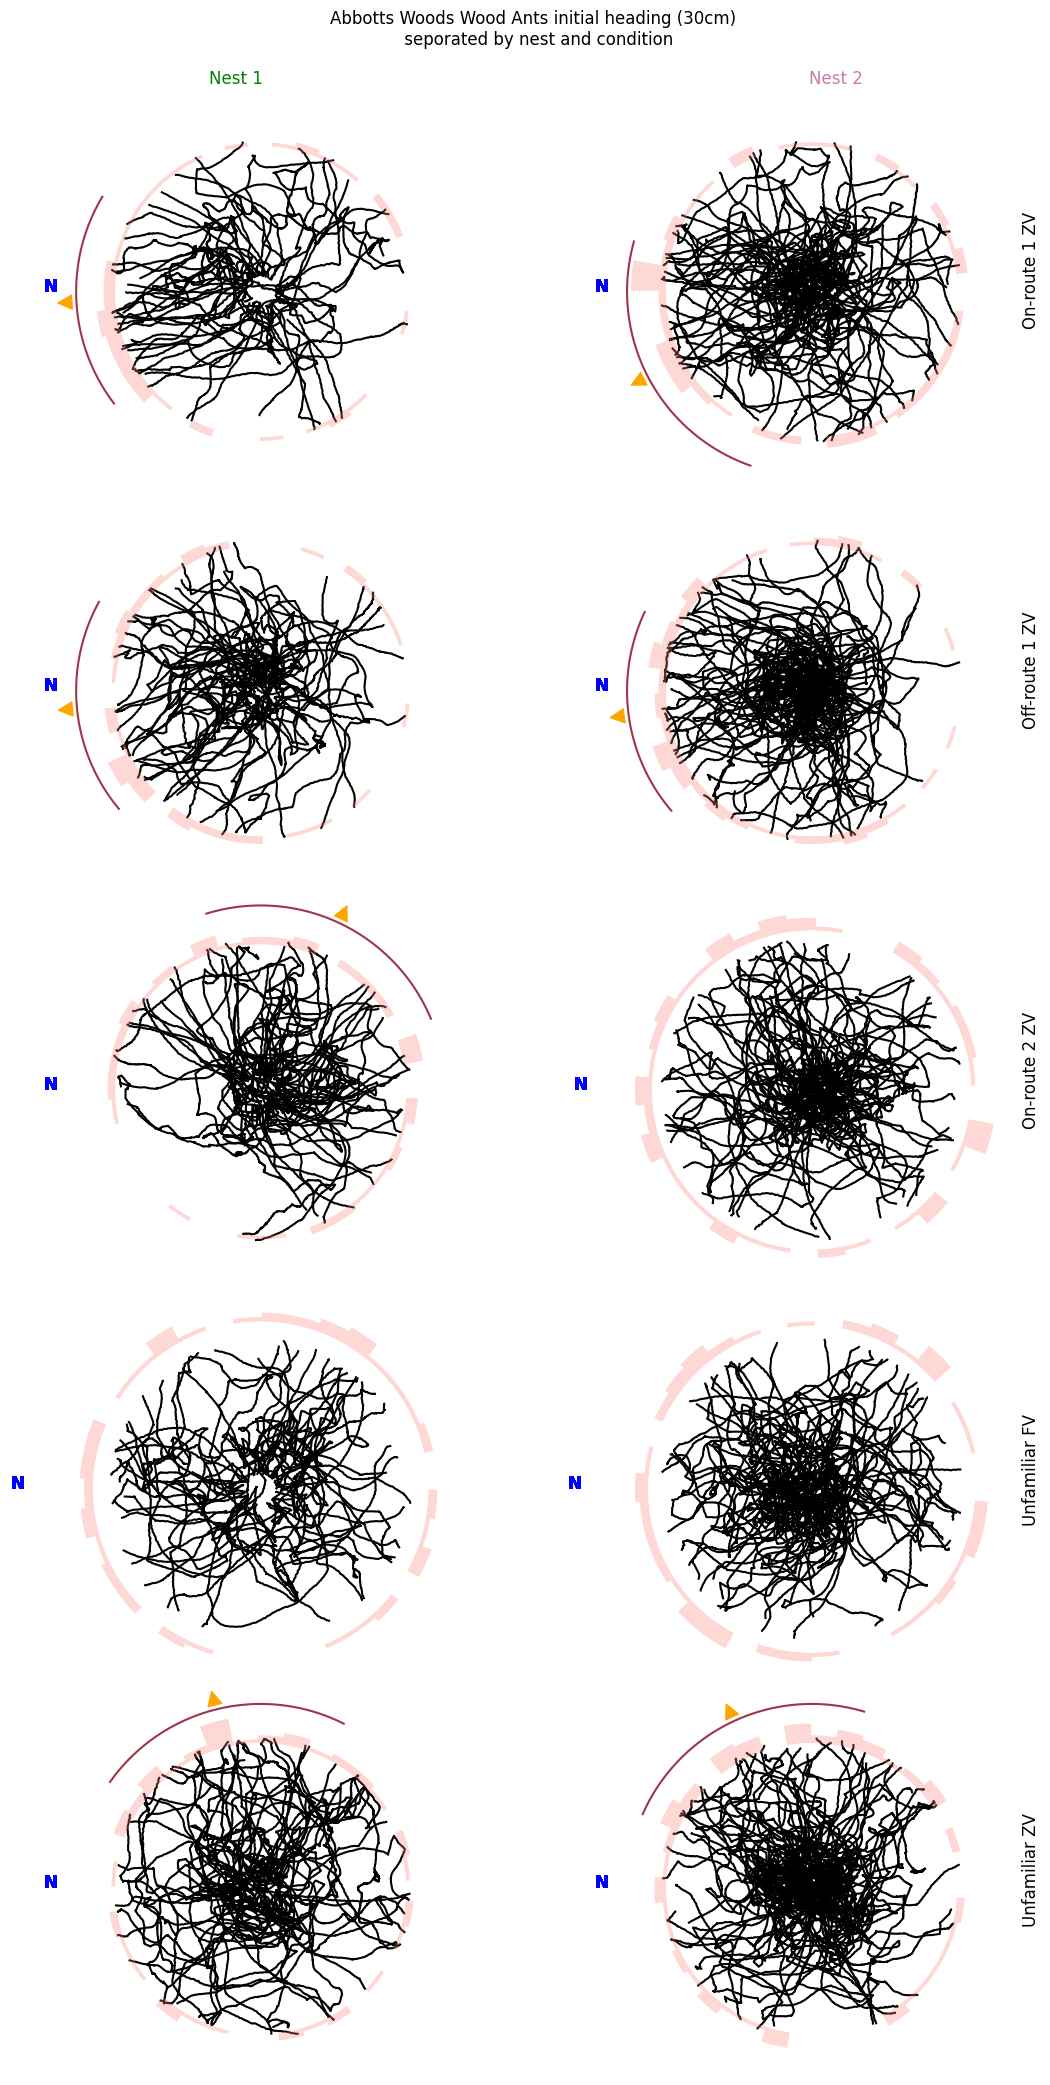

In [372]:
multiTrackplot3(anttracks, Conditions_shared)

In [365]:
conditions_OR1

['On-route 1 ZV', 'On-route 1B ZV', 'Plus 3m ZV', 'Route 0m ZV']

['NewNest' 'Wigwam' 'nan']
['Wigwam', 'NewNest']
 I 0  cond On-route 1 ZV          J 0  nest Wigwam  
       Unnamed: 0.1    index  Unnamed: 0    Date     ID  frame          x  \
79867         79867  36641.0     36641.0  Jul-18  283.0   21.0 -21.776691   

               y    Nest      Condition  ... deltaDist accumDist  speed  time  \
79867 -22.830706  Wigwam  On-route 1 ZV  ...  2.579067       NaN    NaN  0.21   

       meanSpeed  dx  dy  trim_StraightnessIDX  trim_beeline  trim_circR  
79867   6.566669 NaN NaN               0.44002    238.958816    0.220598  

[1 rows x 27 columns]
48
 I 0  cond On-route 1 ZV          J 1  nest NewNest  
        Unnamed: 0.1     index  Unnamed: 0    Date     ID  frame          x  \
608663        608663  478345.0    478345.0  Aug-21  552.0   57.0  33.313953   

               y     Nest      Condition  ... deltaDist accumDist  speed  \
608663  7.757369  NewNest  On-route 1 ZV  ...  5.447718       NaN    NaN   

        time  meanSpeed  dx  dy  trim_

/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


        Unnamed: 0.1      index  Unnamed: 0    Date     ID  frame          x  \
715172        715172  1383539.0   1383539.0  Sep-09  882.0  195.0  16.865669   

                y     Nest       Condition  ... deltaDist accumDist  speed  \
715172 -25.215136  NewNest  On-route 1B ZV  ...  0.520293       NaN    NaN   

        time  meanSpeed  dx  dy  trim_StraightnessIDX  trim_beeline  \
715172  1.95   3.314442 NaN NaN              0.735841    295.620618   

        trim_circR  
715172    0.381834  

[1 rows x 27 columns]
64
 I 2  cond Plus 3m ZV          J 0  nest Wigwam  
Empty DataFrame
Columns: [Unnamed: 0.1, index, Unnamed: 0, Date, ID, frame, x, y, Nest, Condition, Sector, Direction, DI, rad, theta, dTheta, thetaR2N, deltaDist, accumDist, speed, time, meanSpeed, dx, dy, trim_StraightnessIDX, trim_beeline, trim_circR]
Index: []

[0 rows x 27 columns]
0
 I 2  cond Plus 3m ZV          J 1  nest NewNest  


/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


         Unnamed: 0.1      index  Unnamed: 0    Date     ID  frame          x  \
1059956       1059956  2495503.0   2495503.0  Sep-20  116.0   99.0 -21.855935   

                 y     Nest   Condition  ... deltaDist accumDist  speed  time  \
1059956 -20.598213  NewNest  Plus 3m ZV  ...  0.169318       NaN    NaN  0.99   

         meanSpeed  dx  dy  trim_StraightnessIDX  trim_beeline  trim_circR  
1059956   3.398684 NaN NaN              0.260653    292.624159    0.152663  

[1 rows x 27 columns]
34
 I 3  cond Route 0m ZV          J 0  nest Wigwam  
Empty DataFrame
Columns: [Unnamed: 0.1, index, Unnamed: 0, Date, ID, frame, x, y, Nest, Condition, Sector, Direction, DI, rad, theta, dTheta, thetaR2N, deltaDist, accumDist, speed, time, meanSpeed, dx, dy, trim_StraightnessIDX, trim_beeline, trim_circR]
Index: []

[0 rows x 27 columns]
0
 I 3  cond Route 0m ZV          J 1  nest NewNest  


/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


         Unnamed: 0.1      index  Unnamed: 0    Date     ID  frame          x  \
1197238       1197238  2507340.0   2507340.0  Sep-20  112.0   82.0  30.261442   

                y     Nest    Condition  ... deltaDist accumDist  speed  time  \
1197238 -3.636609  NewNest  Route 0m ZV  ...  0.847255       NaN    NaN  0.82   

         meanSpeed  dx  dy  trim_StraightnessIDX  trim_beeline  trim_circR  
1197238   1.312986 NaN NaN              0.380469     255.81962    0.057529  

[1 rows x 27 columns]
43


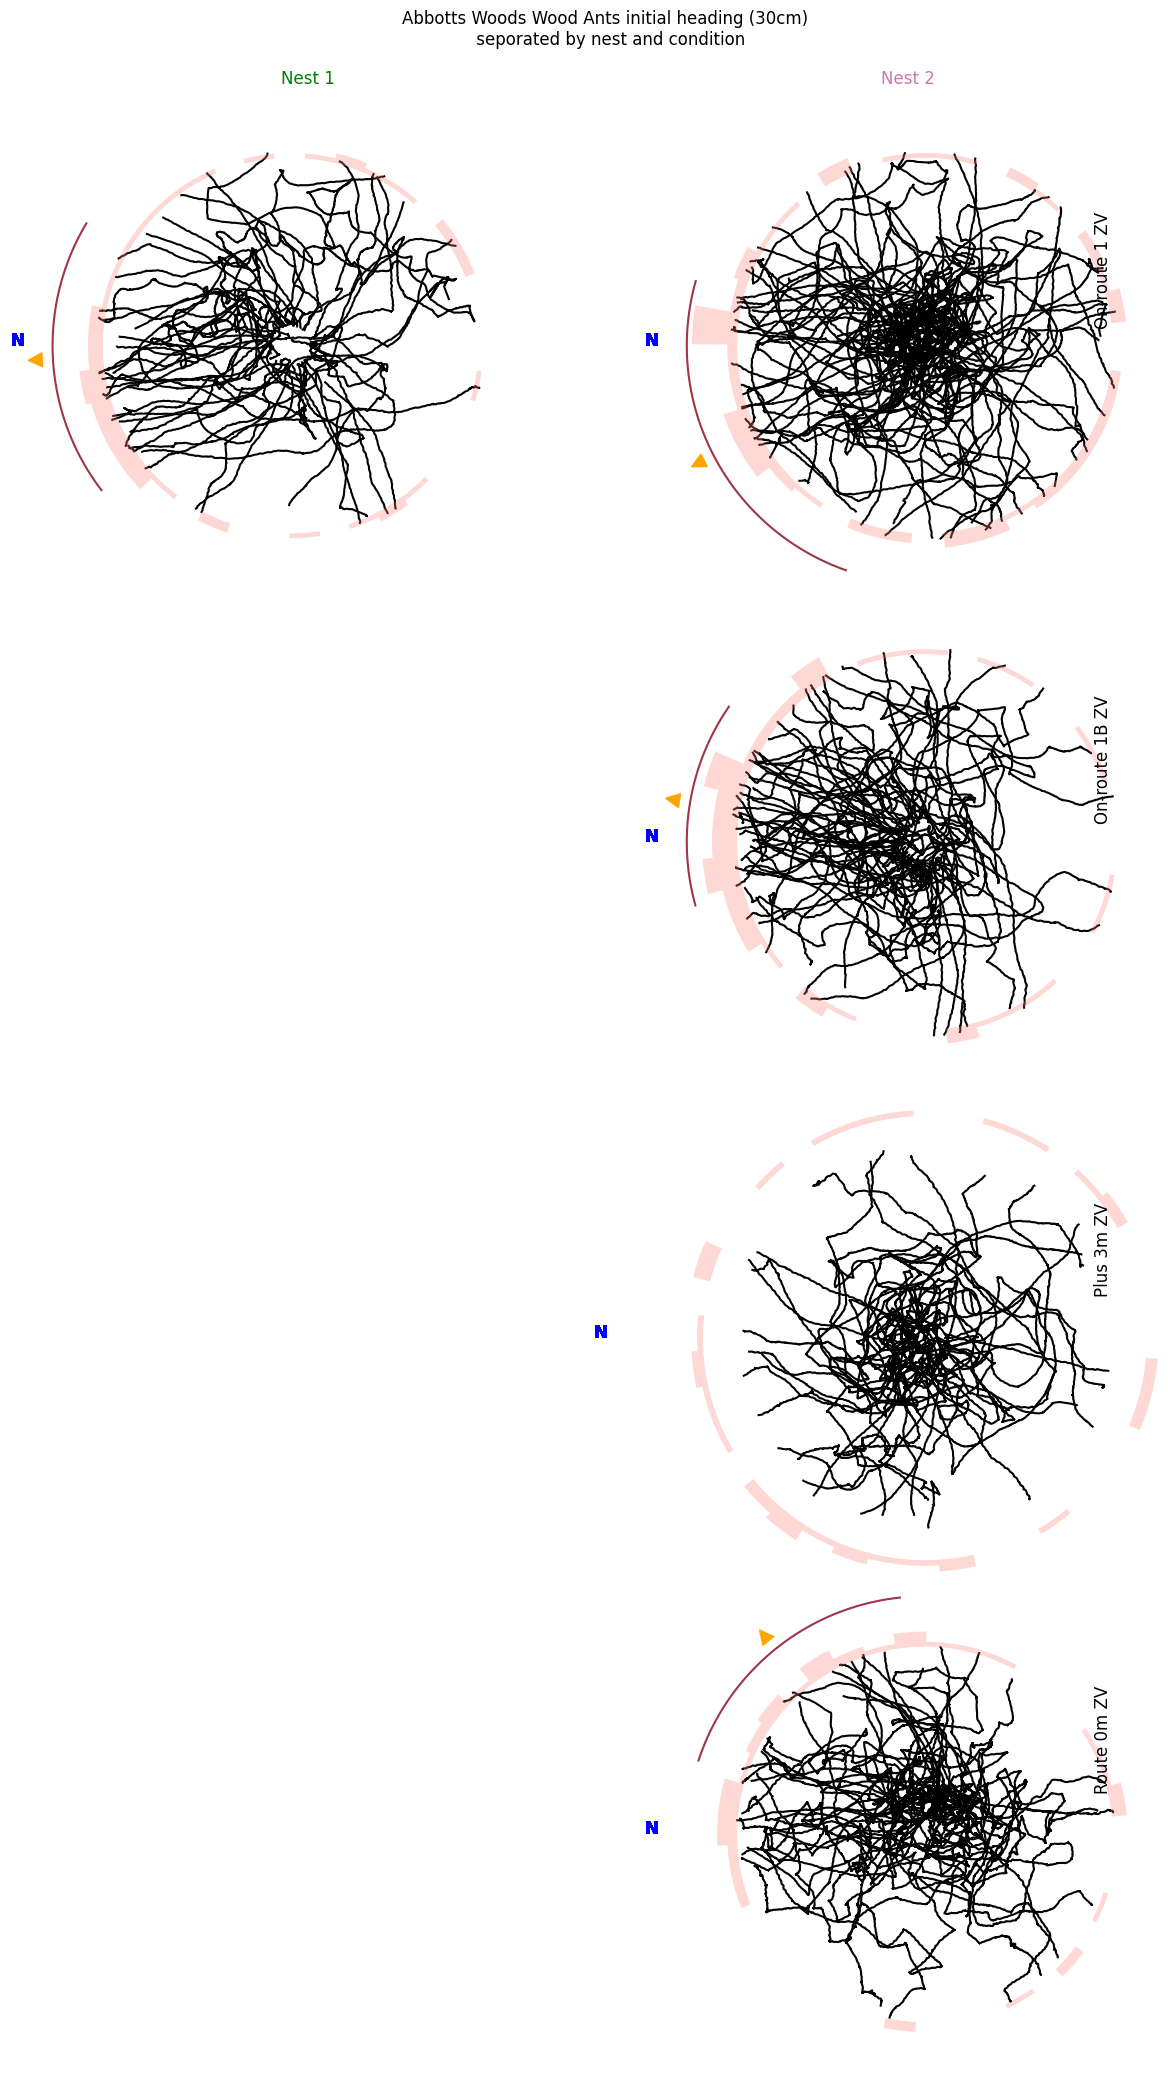

In [373]:
multiTrackplot3(anttracks, conditions_OR1)

In [367]:
condistions_distant

['Unfamiliar ZV', 'Unfamiliar ZV 2', 'Unfamiliar ZV 3', 'Unfamiliar FV']

['NewNest' 'Wigwam' 'nan']
['Wigwam', 'NewNest']
 I 0  cond Unfamiliar ZV          J 0  nest Wigwam  
 I 0  cond Unfamiliar ZV          J 1  nest NewNest  
 I 1  cond Unfamiliar ZV 2          J 0  nest Wigwam  


/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


 I 1  cond Unfamiliar ZV 2          J 1  nest NewNest  
 I 2  cond Unfamiliar ZV 3          J 0  nest Wigwam  


/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:40: RuntimeWarning: invalid value encountered in scalar divide
  C = np.sum(weights * np.cos(p * (data - phi)), axis) / np.sum(weights, axis)
/its/home/nn268/.local/lib/python3.10/site-packages/astropy/stats/circstats.py:41: RuntimeWarning: invalid value encountered in scalar divide
  S = np.sum(weights * np.sin(p * (data - phi)), axis) / np.sum(weights, axis)


 I 2  cond Unfamiliar ZV 3          J 1  nest NewNest  
 I 3  cond Unfamiliar FV          J 0  nest Wigwam  
 I 3  cond Unfamiliar FV          J 1  nest NewNest  


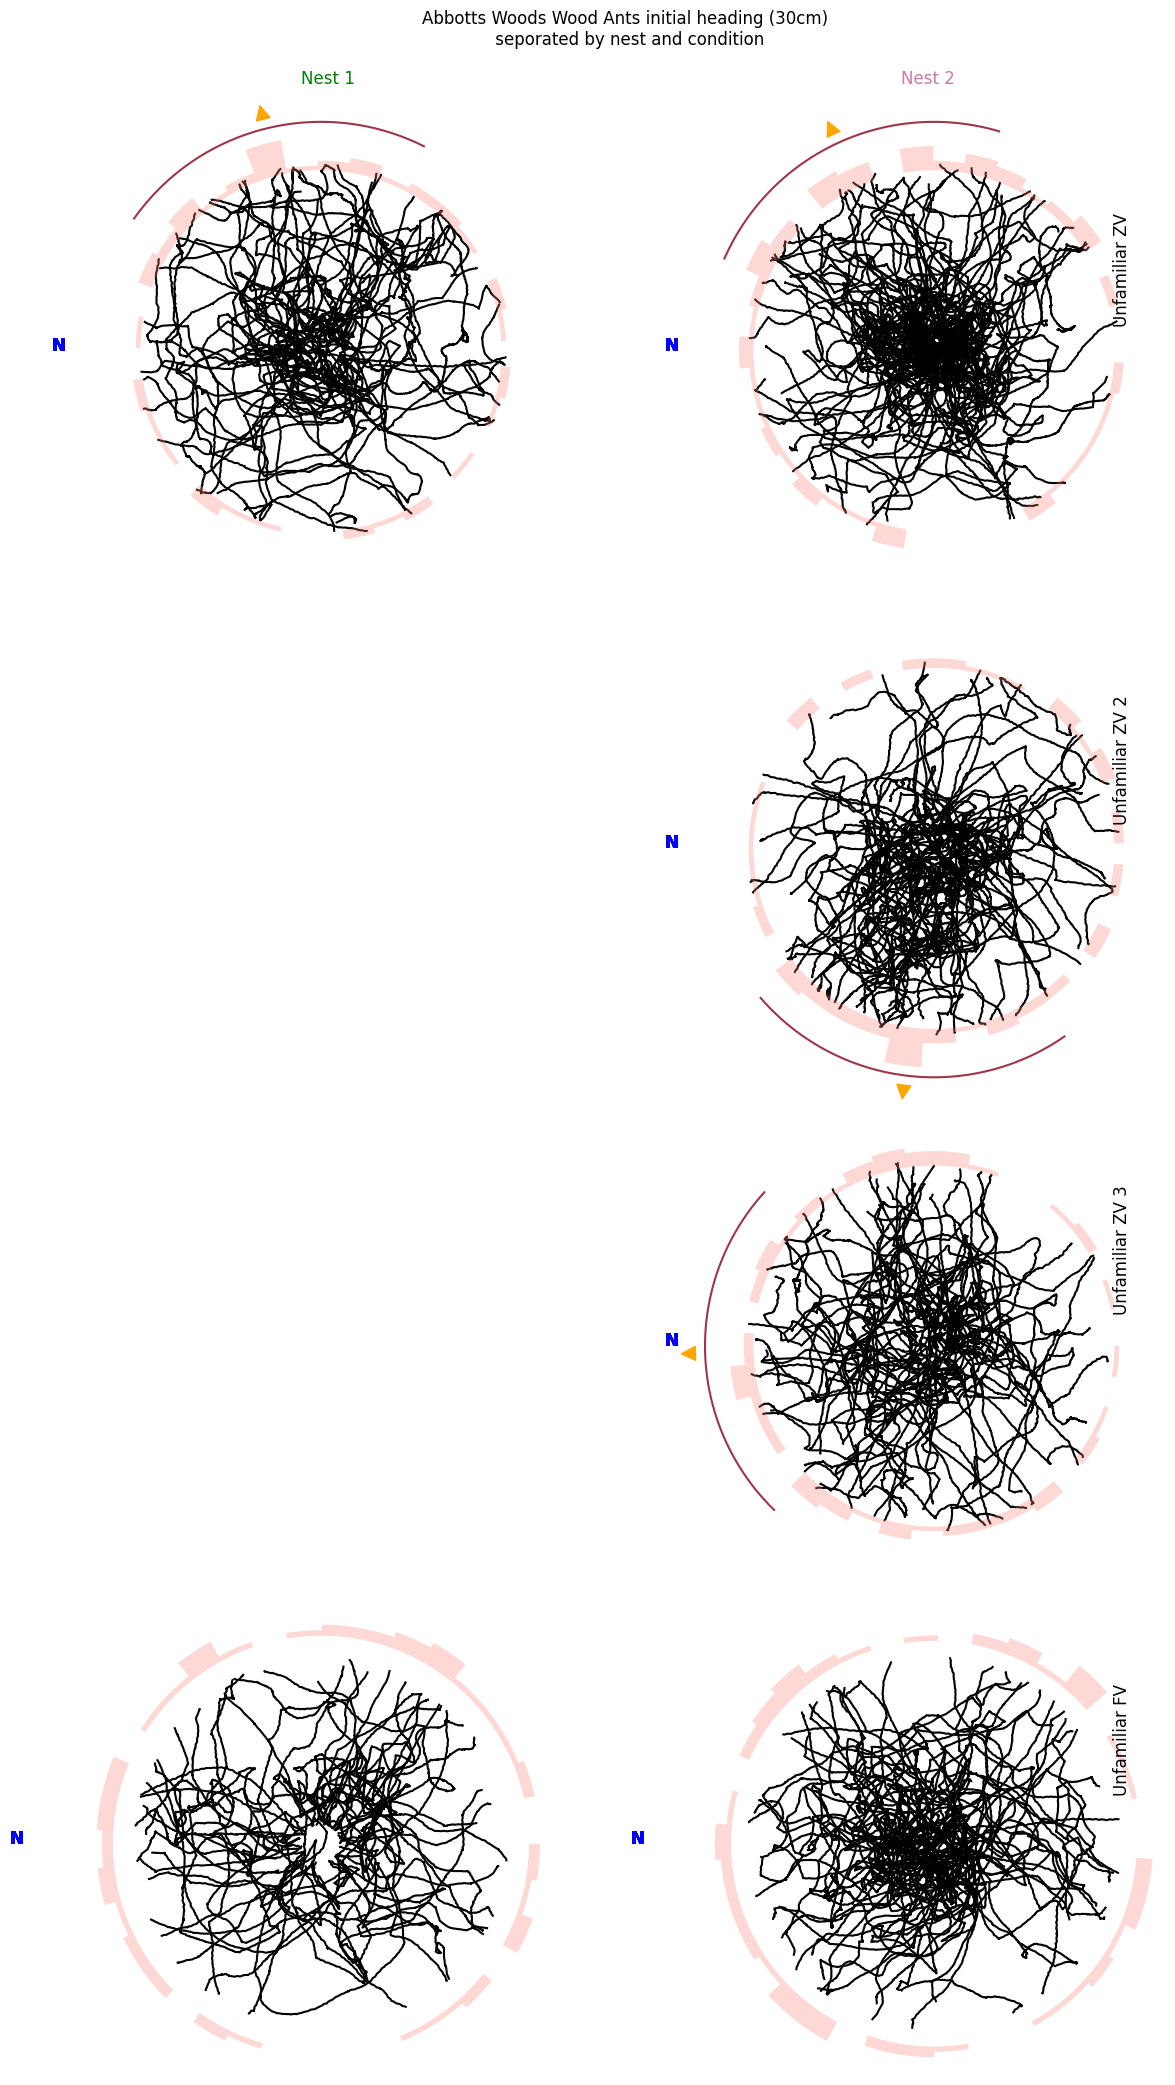

In [368]:
multiTrackplot3(anttracks, condistions_distant)